In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('default')

In [ ]:
orders = pd.read_csv("/content/olist_orders_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")

In [ ]:
print("Orders Data:")
print(orders.head())
print(orders.info())
print(orders.isnull().sum())


print("\nCustomers Data:")
print(customers.head())
print(customers.info())
print(customers.isnull().sum())

Orders Data:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00     

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [ ]:
orders.drop_duplicates(inplace=True)
customers.drop_duplicates(inplace=True)

In [ ]:
orders = orders.dropna()
customers = customers.dropna()

In [ ]:
orders.columns = orders.columns.str.lower()
customers.columns = customers.columns.str.lower()

In [ ]:
df = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="left"
)

In [ ]:
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_day'] = df['order_purchase_timestamp'].dt.day

In [ ]:
customers_orders = df.groupby('customer_id')['order_id'].count().reset_index()
customers_orders.columns = ['customer_id', 'total_orders']

In [ ]:
yearly_orders = df.groupby('order_year')['order_id'].count()
print(yearly_orders)

order_year
2016      272
2017    43411
2018    52778
Name: order_id, dtype: int64


In [ ]:
monthly_orders = df.groupby('order_month')['order_id'].count()
print(monthly_orders)

order_month
1      7817
2      8197
3      9549
4      9101
5     10294
6      9231
7     10028
8     10544
9      4150
10     4748
11     7288
12     5514
Name: order_id, dtype: int64


In [ ]:
top_cities = df['customer_city'].value_counts().head(10)
print(top_cities)

customer_city
sao paulo                15044
rio de janeiro            6603
belo horizonte            2697
brasilia                  2071
curitiba                  1489
campinas                  1406
porto alegre              1341
salvador                  1188
guarulhos                 1143
sao bernardo do campo      911
Name: count, dtype: int64


In [32]:
customer_freq = df.groupby('customer_id')['order_id'].count()

In [34]:
repeat_customers = customer_freq[customer_freq > 1].count()
new_customers = customer_freq[customer_freq == 1].count()

print("Repeat Customers:", repeat_customers)
print("New Customers:", new_customers)

Repeat Customers: 0
New Customers: 96461


In [35]:
monthly_growth = monthly_orders.pct_change()

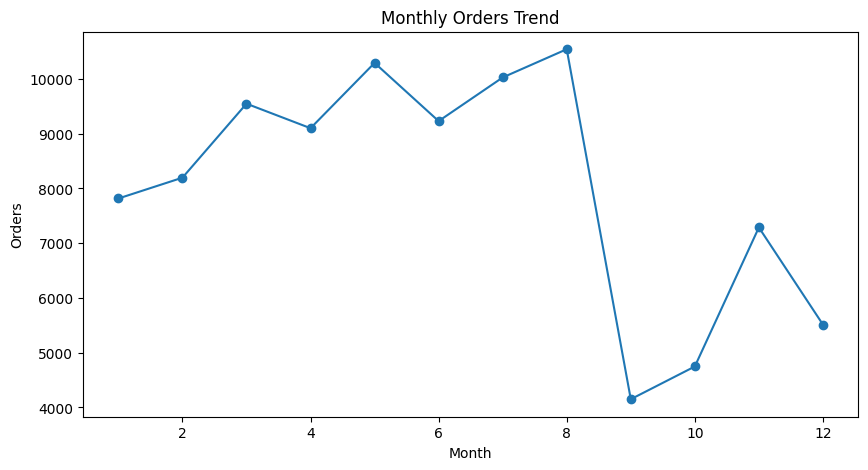

In [36]:
plt.figure(figsize=(10,5))
monthly_orders.plot(marker='o')
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

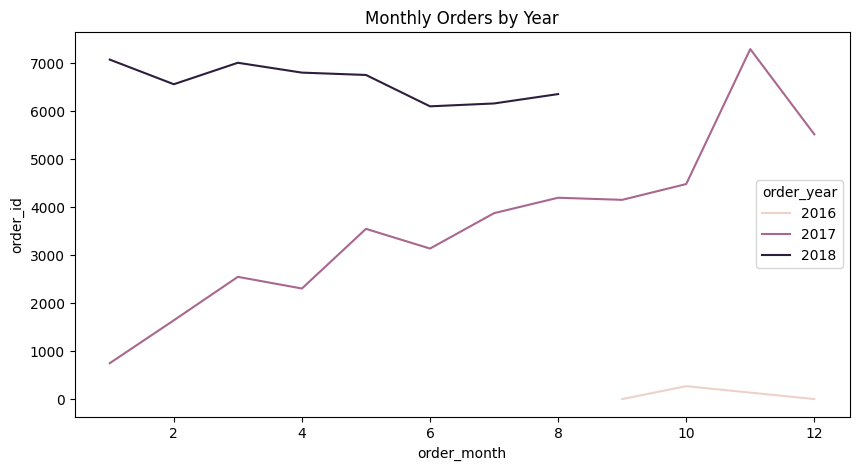

In [37]:
monthly_year = df.groupby(['order_year', 'order_month'])['order_id'].count().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_year, x='order_month', y='order_id', hue='order_year')
plt.title("Monthly Orders by Year")
plt.show()

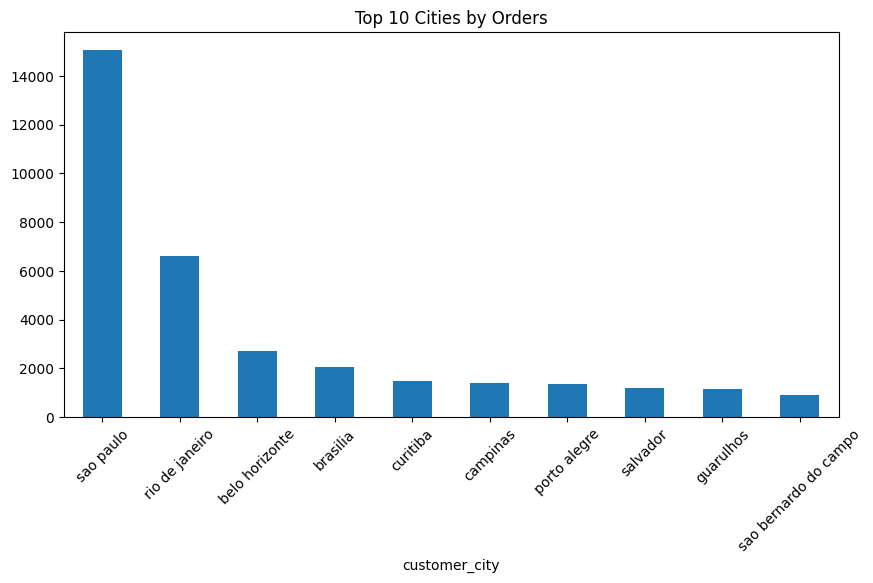

In [38]:
plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title("Top 10 Cities by Orders")
plt.xticks(rotation=45)
plt.show()

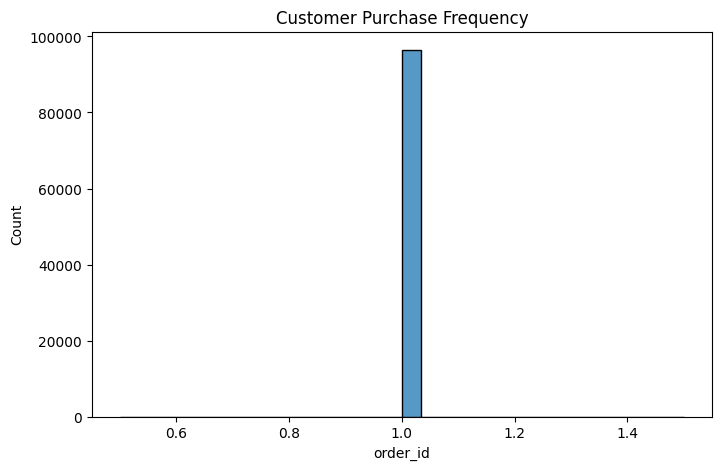

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(customer_freq, bins=30)
plt.title("Customer Purchase Frequency")
plt.show()

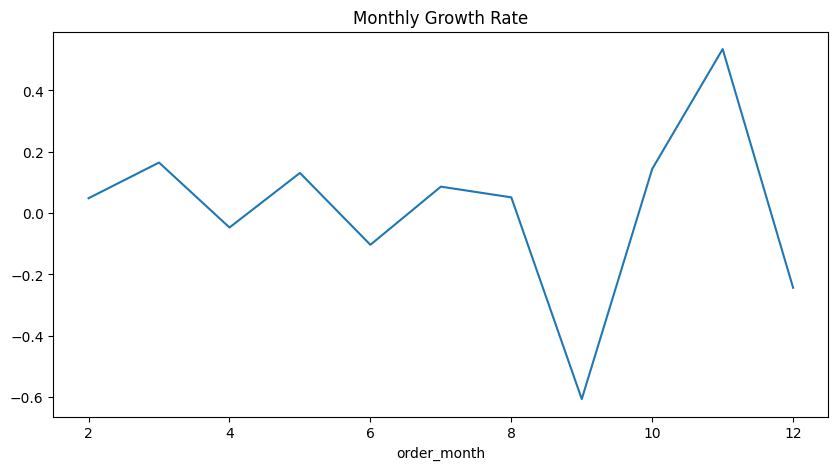

In [41]:
plt.figure(figsize=(10,5))
monthly_growth.plot()
plt.title("Monthly Growth Rate")
plt.show()

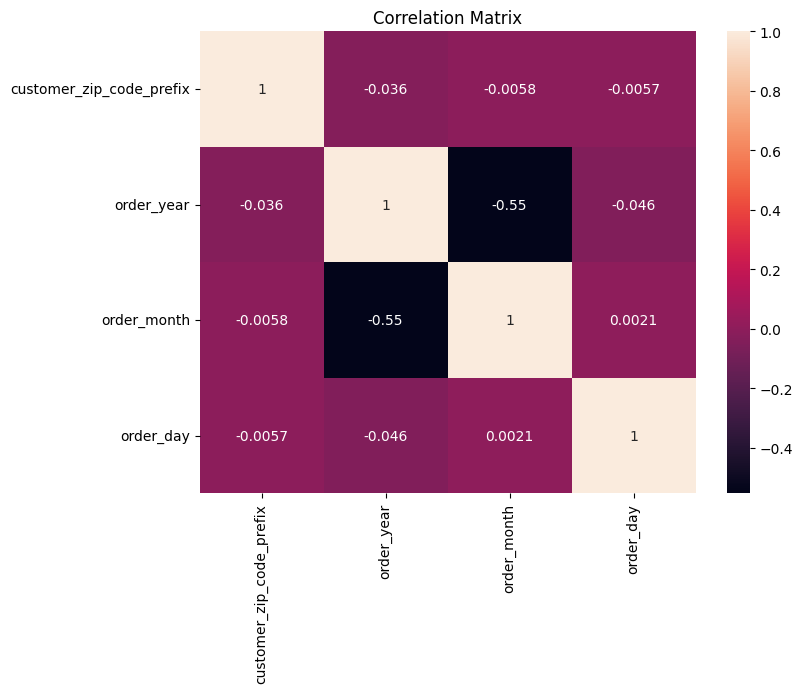

In [42]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

1. Orders show clear seasonal trends with certain month having higher asctivity.
2. A few cities dominate total orders, indicating geographic contration.
3. Most customers are one-time buyers, showing low retention.
4. Repeat customers are fewer but more valuable.
5. growth rate fluctuates, indicating unstable demand patterns.
6. Business should focus on retention and high-performing regions.

In [43]:
df.to_csv("cleaned_olist_data.csv", index=False)

In [45]:
from IPython.display import FileLink
FileLink('cleaned_olist_data.csv')

/content/cleaned_olist_data.csv